In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#Import data and drop rows with missing labels
heart_disease = pd.read_csv("heart-disease.csv")
heart_disease.dropna(subset=["target"] , inplace=True)

#Setup random seed
np.random.seed(42)

# Getting data ready
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split , GridSearchCV

def evaluate_preds(y_true , y_pred):
    """

    """
    accuracy = accuracy_score(y_true , y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true , y_pred)
    f1 = f1_score(y_true , y_pred)

    metric_dict ={"Accuracy":round(accuracy,2),
                  "Recall":round(recall,2),
                  "Precision":round(precision,2),
                  "F1":round(f1,2)}

    print(f"The accuracy score is :{accuracy*100:.2f}%")
    print(f"The Recall score is :{recall:.2f}")
    print(f"The Precision score is :{precision:.2f}")
    print(f"The F1 score is : {f1:.2f}")

    return metric_dict
    
#Define different features and transformer pipeline
categorical_cols = ["cp", "restecg", "slope", "thal"]
binary_cols = ["sex", "fbs", "exang"]
label_encoded_cols = ["ca"]  
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

#Setup preprocessing steps (fill missing values,then convert to numbers)
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first") , categorical_cols),
    ("numerics" , StandardScaler() , numeric_cols)],
                                 remainder="passthrough")

#Creating a preprocessing and modelling pipeline
model = Pipeline(steps=[("preprocessor",preprocessor),
                        ("model" , RandomForestClassifier())])

# use GridSearchCV with our regression pipeline
pipe_grid ={ "model__n_estimators": [100, 1000],
             "model__max_depth": [None, 5],
             "model__max_features": ["sqrt"],
             "model__min_samples_split": [2, 4]}

#Shuffle the data
heart_disease_shuffled = heart_disease.sample(frac=1)

#Split the data
x = heart_disease_shuffled.drop("target",axis=1)
y = heart_disease_shuffled["target"]

#Split into train and test sets
x_train ,x_test , y_train ,y_test = train_test_split(x,y,test_size=0.2)

gs_model = GridSearchCV(model,
                        param_grid=pipe_grid,
                        cv=5,
                        verbose=2)

#Fit the GridSearchCV version of model
gs_model.fit(x_train ,y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100; total time=   1.6s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100; total time=   1.0s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=100; total time=   1.6s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=1000; total time=   8.4s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=1000; total time=  13.1s
[CV] END model__max_depth=No

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__max_depth': [None, 5], 'model__max_features': ['sqrt'], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 1000]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('numerics', ...)]"


In [9]:
from sklearn.metrics import accuracy_score , recall_score ,precision_score , f1_score
gs_y_preds = gs_model.predict(x_test)
gs_metrics = evaluate_preds(y_test , gs_y_preds)

The accuracy score is :77.05%
The Recall score is :0.76
The Precision score is :0.81
The F1 score is : 0.78


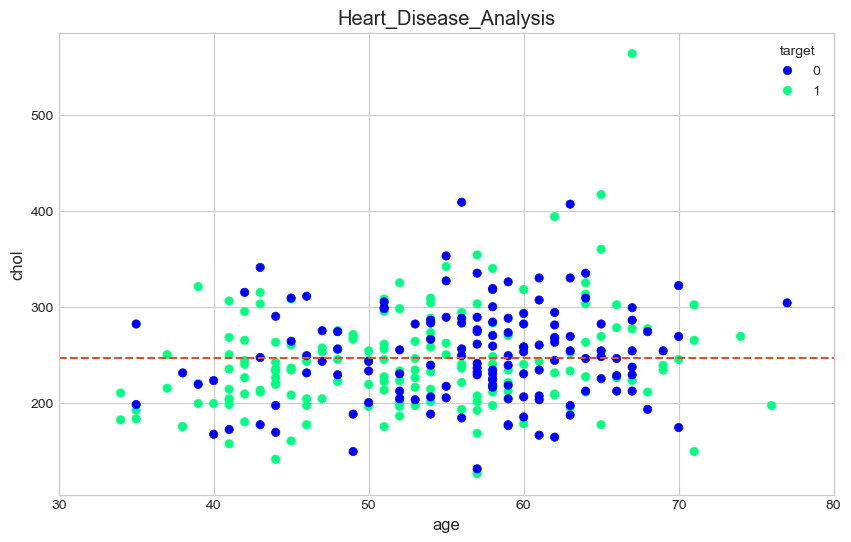

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')
#plt.style.use('ggplot')

fig,ax =plt.subplots(figsize=(10,6))

scatter = ax.scatter(x=heart_disease["age"],
                     y=heart_disease["chol"],
                     c=heart_disease["target"],
                     cmap="winter")
ax.set(title="Heart_Disease_Analysis",
       xlabel="age",
       ylabel="chol")

ax.set_xlim([30,80])

ax.legend(*scatter.legend_elements(),title="target")

ax.axhline(y=heart_disease["chol"].mean(),
           linestyle="--")

plt.show()